In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Global_ECommerce_Customer_Behavior_Dataset_100K.csv")

df.head()

,Customer_ID,Order_ID,Order_Date,Customer_Age,Gender,Country,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Customer_Rating,Total_Spent,Returned,Churn
0,1,ORD000001,2023-09-08,32,Male,India,Sports,1,61,10,Card,3.4,54.90,Yes,Yes
1,2,ORD000002,2024-06-01,56,Male,Canada,Fashion,1,457,5,COD,1.9,434.15,No,Yes
2,3,ORD000003,2023-12-15,35,Male,USA,Home,2,1439,20,Card,1.4,2302.40,Yes,No
3,4,ORD000004,2025-04-06,20,Other,Germany,Sports,3,1246,10,Card,4.9,3364.20,No,Yes
4,5,ORD000005,2025-06-01,41,Other,USA,Electronics,5,610,30,Card,3.6,2135.00,No,Yes


In [2]:
df.shape

(100000, 15)

In [3]:
df.columns

Index(['Customer_ID', 'Order_ID', 'Order_Date', 'Customer_Age', 'Gender',
       'Country', 'Product_Category', 'Quantity', 'Unit_Price', 'Discount',
       'Payment_Method', 'Customer_Rating', 'Total_Spent', 'Returned',
       'Churn'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       100000 non-null  int64  
 1   Order_ID          100000 non-null  str    
 2   Order_Date        100000 non-null  str    
 3   Customer_Age      100000 non-null  int64  
 4   Gender            100000 non-null  str    
 5   Country           100000 non-null  str    
 6   Product_Category  100000 non-null  str    
 7   Quantity          100000 non-null  int64  
 8   Unit_Price        100000 non-null  int64  
 9   Discount          100000 non-null  int64  
 10  Payment_Method    100000 non-null  str    
 11  Customer_Rating   100000 non-null  float64
 12  Total_Spent       100000 non-null  float64
 13  Returned          100000 non-null  str    
 14  Churn             100000 non-null  str    
dtypes: float64(2), int64(5), str(8)
memory usage: 11.4 MB


In [5]:
df.describe()

,Customer_ID,Customer_Age,Quantity,Unit_Price,Discount,Customer_Rating,Total_Spent
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,44.032020,3.002680,1003.188060,13.030550,2.997533,2620.472595
std,28867.657797,15.312205,1.413758,573.990211,10.781938,1.155450,2107.723762
min,1.000000,18.000000,1.000000,10.000000,0.000000,1.000000,7.000000
25%,25000.750000,31.000000,2.000000,508.000000,5.000000,2.000000,946.400000
50%,50000.500000,44.000000,3.000000,1002.000000,10.000000,3.000000,2019.200000
75%,75000.250000,57.000000,4.000000,1500.000000,20.000000,4.000000,3852.000000
max,100000.000000,70.000000,5.000000,2000.000000,30.000000,5.000000,9995.000000


In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [9]:
df["Gender"].value_counts()


Gender
Male      33339
Other     33334
Female    33327
Name: count, dtype: int64

In [10]:
df["Country"].value_counts()

Country
India      20264
Canada     20217
UK         19990
Germany    19910
USA        19619
Name: count, dtype: int64

In [11]:
df["Product_Category"].value_counts()

Product_Category
Fashion        20080
Electronics    20076
Home           20027
Sports         20005
Beauty         19812
Name: count, dtype: int64

In [12]:
df["Payment_Method"].value_counts()

Payment_Method
PayPal    25209
Card      25105
UPI       24902
COD       24784
Name: count, dtype: int64

In [14]:
df["Returned"].value_counts()

Returned
No     50328
Yes    49672
Name: count, dtype: int64

In [15]:
df["Churn"].value_counts()

Churn
Yes    50151
No     49849
Name: count, dtype: int64

In [16]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Customer_ID       100000 non-null  int64         
 1   Order_ID          100000 non-null  str           
 2   Order_Date        100000 non-null  datetime64[us]
 3   Customer_Age      100000 non-null  int64         
 4   Gender            100000 non-null  str           
 5   Country           100000 non-null  str           
 6   Product_Category  100000 non-null  str           
 7   Quantity          100000 non-null  int64         
 8   Unit_Price        100000 non-null  int64         
 9   Discount          100000 non-null  int64         
 10  Payment_Method    100000 non-null  str           
 11  Customer_Rating   100000 non-null  float64       
 12  Total_Spent       100000 non-null  float64       
 13  Returned          100000 non-null  str           
 14  Churn           

In [19]:
df["Expected_Total"] = (
    df["Quantity"]
    * df["Unit_Price"]
    * (1 - df["Discount"] / 100)
)

In [23]:
df["Difference"] = df["Total_Spent"] - df["Expected_Total"]

In [ ]:
df["Difference"]

In [25]:
df.drop(columns=["Expected_Total", "Difference"], inplace=True)

In [26]:
df["Year"] = df["Order_Date"].dt.year

In [27]:
df["Month"] = df["Order_Date"].dt.month_name()

In [29]:
df["Month_Number"] = df["Order_Date"].dt.month

In [30]:
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

In [32]:
bins = [0, 25, 35, 45, 60, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-60",
    "60+"
]

df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=bins,
    labels=labels
)

In [35]:
bins = [1,2,3,4,5]

labels = [
    "Poor",
    "Low",
    "Good",
    "Excellent"
]

df["Rating_Group"] = pd.cut(
    df["Customer_Rating"],
    bins=bins,
    labels=labels
)

In [62]:
category_revenue = (
    df.groupby("Product_Category")["Total_Spent"]
      .sum()
      .sort_values(ascending=False)
)


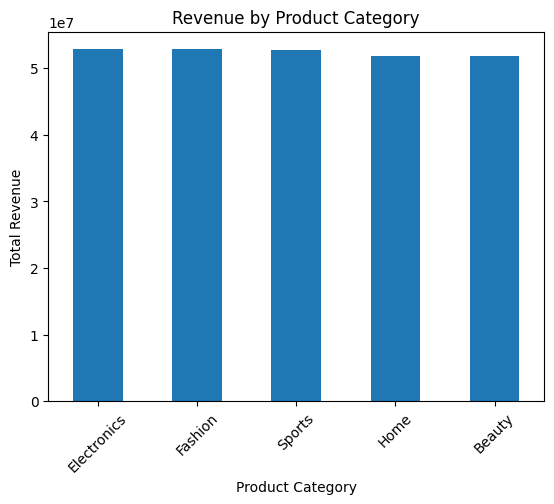

In [53]:
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

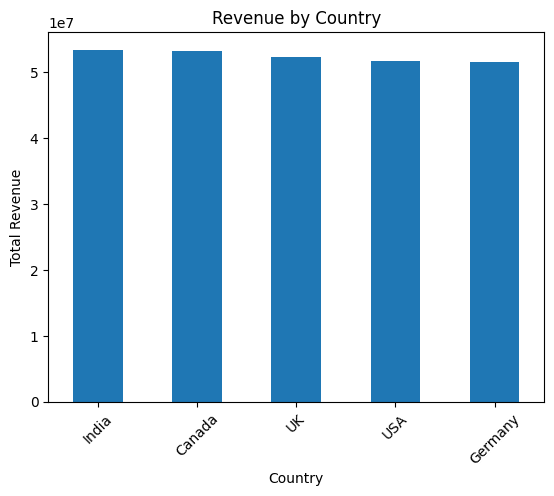

In [56]:
country_revenue = (
    df.groupby("Country")["Total_Spent"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.plot(kind="bar")

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [39]:
df.groupby("Gender")["Total_Spent"].sum()

Gender
Female    87444096.35
Male      87508599.85
Other     87094563.30
Name: Total_Spent, dtype: float64

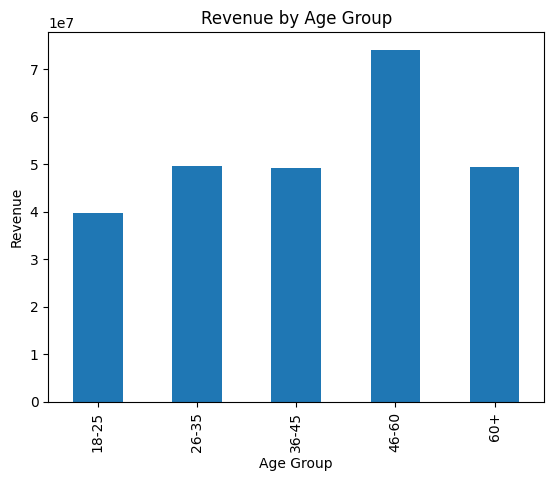

In [63]:
age_revenue = (
    df.groupby("Age_Group", observed=True)["Total_Spent"]
      .sum()
)

age_revenue.plot(kind="bar")

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

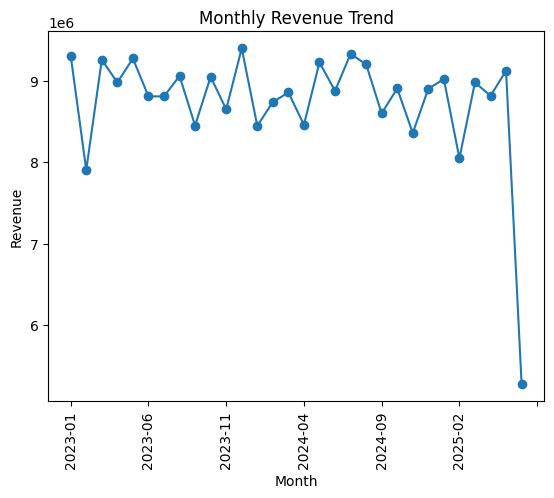

In [ ]:
monthly_revenue = (
    df.groupby("Year_Month")["Total_Spent"]
      .sum()
)

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

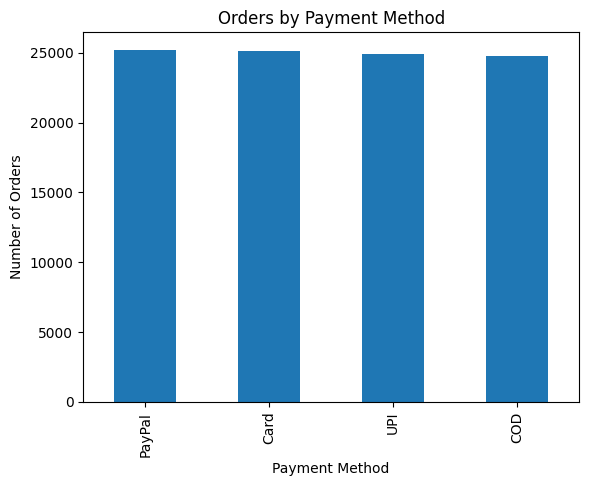

In [61]:
payment_counts = df["Payment_Method"].value_counts()

payment_counts.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

In [64]:
df["Return_Flag"] = df["Returned"].map({
    "Yes": 1,
    "No": 0
})

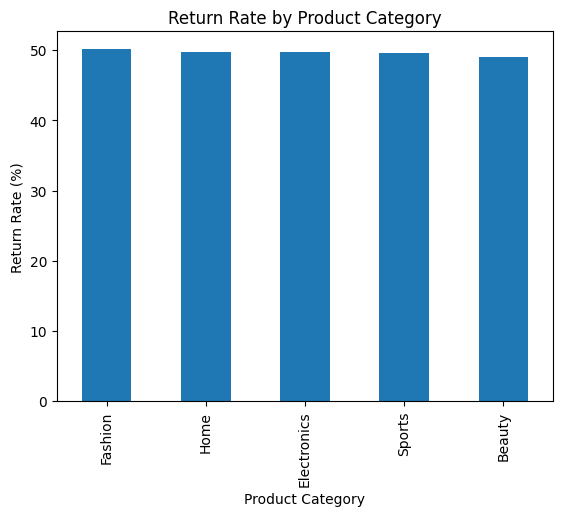

In [ ]:
return_rate = (
    df.groupby("Product_Category")["Return_Flag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

return_rate.plot(kind="bar")

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.show()

In [66]:
df["Churn_Flag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

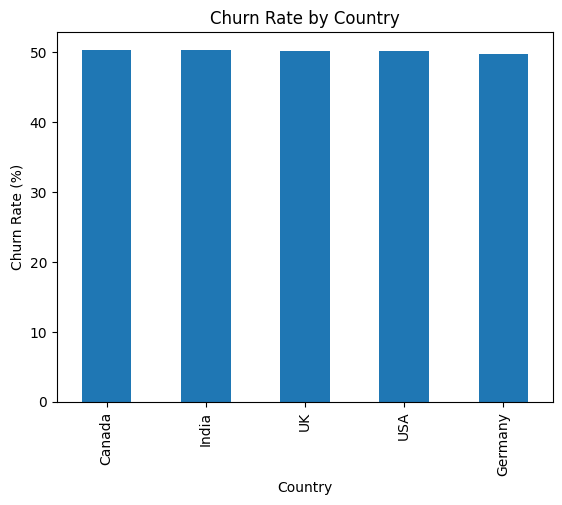

In [67]:
churn_country = (
    df.groupby("Country")["Churn_Flag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

churn_country.plot(kind="bar")

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.show()

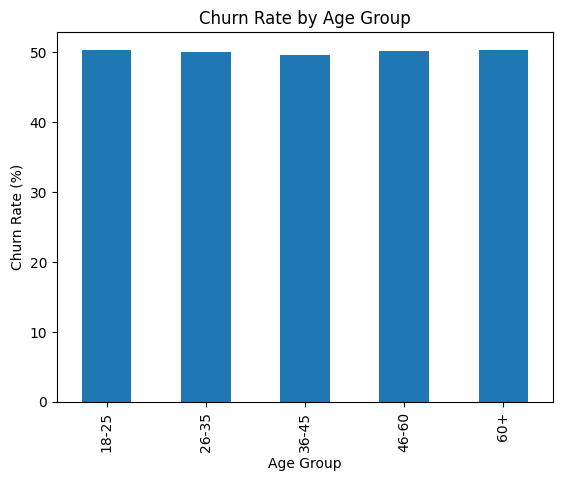

In [68]:
churn_age = (
    df.groupby("Age_Group", observed=True)["Churn_Flag"]
      .mean()
      .mul(100)
)

churn_age.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

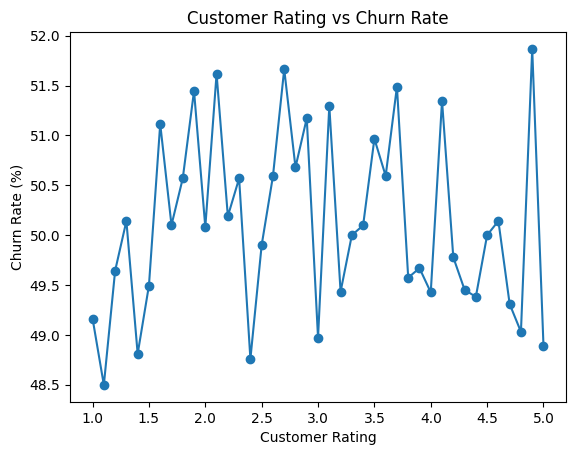

In [69]:
rating_churn = (
    df.groupby("Customer_Rating")["Churn_Flag"]
      .mean()
      .mul(100)
)

rating_churn.plot(kind="line", marker="o")

plt.title("Customer Rating vs Churn Rate")
plt.xlabel("Customer Rating")
plt.ylabel("Churn Rate (%)")
plt.show()

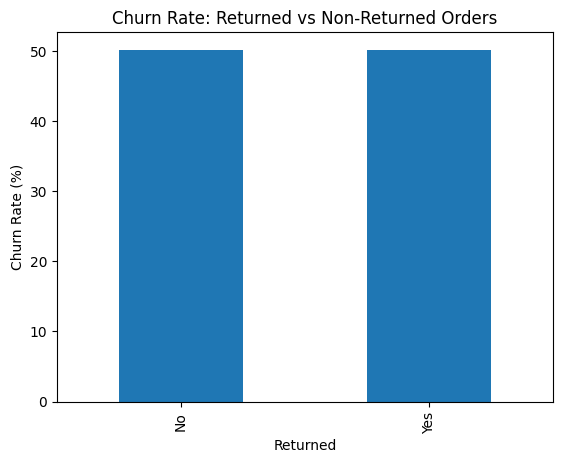

In [70]:
return_churn = (
    df.groupby("Returned")["Churn_Flag"]
      .mean()
      .mul(100)
)

return_churn.plot(kind="bar")

plt.title("Churn Rate: Returned vs Non-Returned Orders")
plt.xlabel("Returned")
plt.ylabel("Churn Rate (%)")
plt.show()

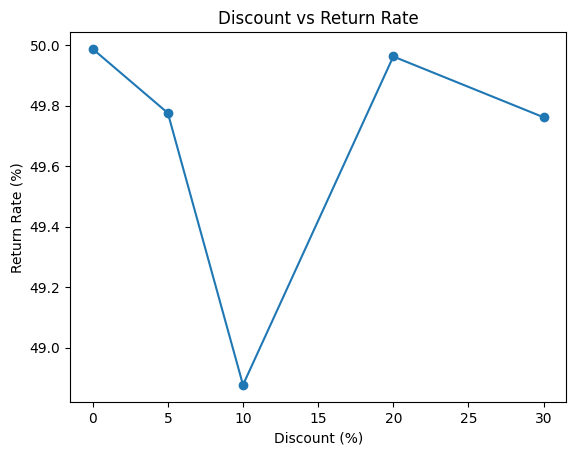

In [71]:
discount_return = (
    df.groupby("Discount")["Return_Flag"]
      .mean()
      .mul(100)
)

discount_return.plot(kind="line", marker="o")

plt.title("Discount vs Return Rate")
plt.xlabel("Discount (%)")
plt.ylabel("Return Rate (%)")
plt.show()

In [72]:
df.head()

,Customer_ID,Order_ID,Order_Date,Customer_Age,Gender,Country,Product_Category,Quantity,Unit_Price,Discount,...,Returned,Churn,Year,Month,Month_Number,Year_Month,Age_Group,Rating_Group,Return_Flag,Churn_Flag
0,1,ORD000001,2023-09-08,32,Male,India,Sports,1,61,10,...,Yes,Yes,2023,September,9,2023-09,26-35,Good,1,1
1,2,ORD000002,2024-06-01,56,Male,Canada,Fashion,1,457,5,...,No,Yes,2024,June,6,2024-06,46-60,Poor,0,1
2,3,ORD000003,2023-12-15,35,Male,USA,Home,2,1439,20,...,Yes,No,2023,December,12,2023-12,26-35,Poor,1,0
3,4,ORD000004,2025-04-06,20,Other,Germany,Sports,3,1246,10,...,No,Yes,2025,April,4,2025-04,18-25,Excellent,0,1
4,5,ORD000005,2025-06-01,41,Other,USA,Electronics,5,610,30,...,No,Yes,2025,June,6,2025-06,36-45,Good,0,1


In [73]:
df.to_csv("Cleaned_Ecommerce_Dataset.csv", index=False)

In [75]:
from sqlalchemy import create_engine
username = "root"
password = "NewPassword123"
host = "localhost"
port = "3306"
database = "ecommerce_analysis"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)


In [76]:
df.to_sql(
    name="orders",
    con=engine,
    if_exists="replace",
    index=False
)

100000